# Chapel Hill Housing Valuation

Estimate a fair value for homes in the Chapel Hill / Carrboro / Orange County, NC area using
real-estate finance, compare it to each home's asking price, and map which homes look
under- or over-priced.

The model builds its **own** valuation from four methods.

Fair value is anchored mostly to things **independent of asking prices** such as rent, rebuild
cost, and local incomes so the over/under signal reflects real economics, not just how one
listing compares to another.


## Setup

In [74]:
!pip install -q folium requests 2>/dev/null
import os, json, time, warnings
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import folium
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams.update({"figure.figsize": (11, 5), "axes.titleweight": "bold"})
CURRENT_YEAR = 2025

## API Keys and Limits



In [75]:
API_KEYS = {"RENTCAST": "", "CENSUS": "", "FRED": ""}
try:
    from google.colab import userdata
    for k, secret in [("RENTCAST","RENTCAST_API_KEY"),
                      ("CENSUS","CENSUS_API_KEY"), ("FRED","FRED_API_KEY")]:
        API_KEYS[k] = userdata.get(secret) or API_KEYS[k]
except Exception:
    pass

CONFIG = {
    "RENTCAST_MONTHLY_LIMIT": 50,
    "RENTCAST_HARD_CAP": 48,
    "RENTCAST_REQUESTS_ALREADY_USED": 0,   # set to your dashboard's "used" count
    "MAX_PROPERTIES": 40,
}
CACHE_DIR = "/content/api_cache"
os.makedirs(CACHE_DIR, exist_ok=True)
USAGE_FILE = os.path.join(CACHE_DIR, "rentcast_usage.json")

def load_api_usage():
    if os.path.exists(USAGE_FILE):
        return json.load(open(USAGE_FILE))
    return {"rentcast_requests_this_period": CONFIG["RENTCAST_REQUESTS_ALREADY_USED"]}

def save_api_usage(u):
    json.dump(u, open(USAGE_FILE, "w"))

API_USAGE = load_api_usage()

def rentcast_remaining():
    return CONFIG["RENTCAST_HARD_CAP"] - API_USAGE["rentcast_requests_this_period"]

def rentcast_get(url, headers=None, params=None, timeout=30):
    """Single gateway for RentCast calls: enforces the hard cap and logs usage."""
    if rentcast_remaining() <= 0:
        raise RuntimeError(f"RentCast hard cap reached ({CONFIG['RENTCAST_HARD_CAP']}).")
    API_USAGE["rentcast_requests_this_period"] += 1
    save_api_usage(API_USAGE)
    print(f"RentCast API request {API_USAGE['rentcast_requests_this_period']} "
          f"of {CONFIG['RENTCAST_HARD_CAP']}")
    return requests.get(url, headers=headers, params=params, timeout=timeout)

assert CONFIG["RENTCAST_HARD_CAP"] <= CONFIG["RENTCAST_MONTHLY_LIMIT"]
assert CONFIG["MAX_PROPERTIES"] > 0
print("Setup checks passed. RentCast remaining:", rentcast_remaining())

Setup checks passed. RentCast remaining: 47


## Assumptions

The cost-approach figures
(construction and land cost per sqft) are regional estimates.

In [76]:
ASSUMPTIONS = {
    "down_payment_pct": 0.20, "mortgage_term_years": 30,
    "property_tax_rate": 0.011, "insurance_rate": 0.0035, "maintenance_rate": 0.010,
    "vacancy_rate": 0.055, "management_rate": 0.080,
    "closing_cost_buy_pct": 0.025, "selling_cost_pct": 0.060,
    "base_cap_rate": 0.0575,
    "affordability_dti": 0.33, "income_buffer_pct": 0.90,
    "construction_cost_per_sqft": 320, "land_value_per_lot_sqft": 28,
    "annual_depreciation": 0.010, "max_depreciation": 0.40,
    "fair_value_band": 0.10,
    "weights": {"income": 0.35, "cost": 0.30, "comp": 0.25, "affordability": 0.10},
    "land_value_cap_ratio": 0.50,
}
CENTER = {"lat": 35.9132, "lon": -79.0558}
REQUIRED_LISTING_COLUMNS = ["property_id","address","city","state","zip_code","latitude",
    "longitude","property_type","beds","baths","sqft","lot_sqft","year_built",
    "asking_price","monthly_rent"]

## Macro Inputs



In [77]:
def get_mortgage_rate():
    try:
        url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"
        s = pd.read_csv(url).dropna()
        rate = float(s.iloc[-1, 1]) / 100.0
        if 0 < rate < 0.20:
            print("Mortgage rate source: FRED MORTGAGE30US")
            return rate
    except Exception:
        pass
    print("Mortgage rate source: default assumption")
    return 0.0675

def get_local_context():
    ctx = {"median_household_income": 95000, "median_home_value": 575000,
           "median_gross_rent": 2100, "source": "default assumptions"}
    key = API_KEYS["CENSUS"]
    if key:
        for year in [2023, 2022, 2021, 2020]:
            try:
                url = (f"https://api.census.gov/data/{year}/acs/acs5"
                       f"?get=B19013_001E,B25077_001E,B25064_001E"
                       f"&for=county:135&in=state:37&key={key}")  # Orange County, NC
                r = requests.get(url, timeout=20).json()
                vals = r[1]
                ctx.update({"median_household_income": float(vals[0]),
                            "median_home_value": float(vals[1]),
                            "median_gross_rent": float(vals[2]),
                            "source": f"Census ACS {year} (Orange County, NC)"})
                break
            except Exception:
                continue
    print("Local context source:", ctx["source"])
    return ctx

MORTGAGE_RATE = get_mortgage_rate()
LOCAL_CONTEXT = get_local_context()
MARKET_TREND = {"annual_appreciation": 0.035, "source": "default assumption"}

assert 0 < MORTGAGE_RATE < 0.20
assert LOCAL_CONTEXT["median_household_income"] > 0
print("Macro checks passed. Mortgage rate: {:.2%}".format(MORTGAGE_RATE))

Mortgage rate source: FRED MORTGAGE30US
Local context source: default assumptions
Macro checks passed. Mortgage rate: 6.47%


## Data

Try RentCast live listings if a key is present (cached for 24h to save requests).

In [78]:
def load_rentcast_listings():
    """One cached bulk request. Raises on any problem so the caller falls back."""
    cache = os.path.join(CACHE_DIR, "rentcast_listings_chapel_hill.json")
    if os.path.exists(cache) and (time.time()-os.path.getmtime(cache)) < 86400:
        print(f"Found cached RentCast response from "
              f"{(time.time()-os.path.getmtime(cache))/3600:.1f} hours ago. Using cache.")
        raw = json.load(open(cache))
    else:
        if not API_KEYS["RENTCAST"]:
            raise RuntimeError("No RentCast key.")
        headers = {"X-Api-Key": API_KEYS["RENTCAST"], "accept": "application/json"}
        url = "https://api.rentcast.io/v1/listings/sale"
        resp = rentcast_get(url, headers=headers,
                            params={"city": "Chapel Hill", "state": "NC",
                                    "limit": CONFIG["MAX_PROPERTIES"]})
        if resp.status_code != 200:
            raise RuntimeError(f"RentCast status {resp.status_code}")
        raw = resp.json()
        json.dump(raw, open(cache, "w"))
    rows = raw if isinstance(raw, list) else raw.get("listings", raw.get("data", []))
    if not rows:
        raise RuntimeError("Empty RentCast response.")
    recs = []
    for i, p in enumerate(rows):
        recs.append({
            "property_id": p.get("id", f"RC{i:03d}"),
            "address": p.get("formattedAddress", p.get("addressLine1", "")),
            "city": p.get("city", "Chapel Hill"), "state": p.get("state", "NC"),
            "zip_code": str(p.get("zipCode", "")), "latitude": p.get("latitude"),
            "longitude": p.get("longitude"),
            "property_type": (p.get("propertyType", "single_family") or "single_family").lower(),
            "beds": p.get("bedrooms"), "baths": p.get("bathrooms"),
            "sqft": p.get("squareFootage"), "lot_sqft": p.get("lotSize"),
            "year_built": p.get("yearBuilt"), "asking_price": p.get("price"),
            "monthly_rent": p.get("rent")})
    df = pd.DataFrame(recs).dropna(subset=["latitude","longitude","sqft","asking_price"])
    if len(df) == 0:
        raise RuntimeError("No usable RentCast rows.")
    return df

STREETS = ["Franklin Grove","Rosemary Ridge","Estes Park","Weaver Dairy","Homestead Oaks",
           "Morgan Creek","Meadowmont","Southern Village","Booker Creek","Carrboro Mill"]

def generate_synthetic(n=40, seed=42):
    rng = np.random.default_rng(seed)
    types = rng.choice(["single_family","townhouse","condo"], n, p=[0.55,0.25,0.20])
    sqft = np.where(types=="single_family", rng.uniform(1800,4200,n),
           np.where(types=="townhouse", rng.uniform(1200,2400,n),
                    rng.uniform(700,1500,n))).round(0)
    tp = np.array([{"single_family":1.0,"townhouse":0.95,"condo":0.90}[t] for t in types])
    loc = rng.uniform(0.85, 1.25, n)
    true_value = sqft*300*loc*tp*(1+rng.normal(0,0.05,n))
    asking = (true_value*(1+rng.normal(0,0.13,n))).round(-3)
    cap_target = np.clip(rng.normal(0.094,0.010,n), 0.06, 0.13)
    monthly_rent = (true_value*cap_target/12).round(-1)
    lot = np.where(types=="single_family", rng.uniform(6000,20000,n),
          np.where(types=="townhouse", rng.uniform(2000,5000,n),
                   rng.uniform(0,1200,n))).round(0)
    return pd.DataFrame({
        "property_id":[f"SYN{i:03d}" for i in range(n)],
        "address":[f"{rng.integers(100,999)} {rng.choice(STREETS)}" for _ in range(n)],
        "city":"Chapel Hill","state":"NC","zip_code":"27514",
        "latitude":CENTER["lat"]+rng.uniform(-0.08,0.08,n),
        "longitude":CENTER["lon"]+rng.uniform(-0.10,0.10,n),
        "property_type":types,
        "beds":np.clip((sqft/700).round(0),1,6).astype(int),
        "baths":np.clip((sqft/900).round(0),1,5).astype(int),
        "sqft":sqft,"lot_sqft":lot,"year_built":rng.integers(1958,2021,n),
        "asking_price":asking,"monthly_rent":monthly_rent})

try:
    listings = load_rentcast_listings()
    DATA_SOURCE = "RentCast live API"
except Exception as e:
    listings = generate_synthetic(CONFIG["MAX_PROPERTIES"])
    DATA_SOURCE = "synthetic Chapel Hill housing data"

# Fill any missing rent with a simple local rent model
# Fill missing fields so the valuation never hits a blank value (live data is messy)
rent_psf = LOCAL_CONTEXT["median_gross_rent"] / max(listings["sqft"].median(), 1)
listings["monthly_rent"] = listings["monthly_rent"].fillna(listings["sqft"] * rent_psf)

# lot size: fall back to a typical lot by property type, then overall median
type_lot = listings.groupby("property_type")["lot_sqft"].transform("median")
listings["lot_sqft"] = listings["lot_sqft"].fillna(type_lot).fillna(listings["lot_sqft"].median())
listings["lot_sqft"] = listings["lot_sqft"].fillna(5000)  # last-resort default

# year built: fall back to median, then a reasonable default
listings["year_built"] = listings["year_built"].fillna(listings["year_built"].median()).fillna(1990)

# beds / baths: fall back to size-based estimate
listings["beds"] = listings["beds"].fillna((listings["sqft"] / 700).round().clip(1, 6))
listings["baths"] = listings["baths"].fillna((listings["sqft"] / 900).round().clip(1, 5))

# drop any row still missing the truly essential fields (can't value without these)
listings = listings.dropna(subset=["sqft", "asking_price", "monthly_rent",
                                    "latitude", "longitude"])

missing = [c for c in REQUIRED_LISTING_COLUMNS if c not in listings.columns]
assert not missing, f"Missing columns: {missing}"
assert len(listings) > 0 and listings["asking_price"].gt(0).all()
assert listings["sqft"].gt(0).all() and listings["monthly_rent"].gt(0).all()
print(f"Loaded {len(listings)} properties.")
print(f"Data source: {DATA_SOURCE}")

Found cached RentCast response from 1.4 hours ago. Using cache.
Loaded 29 properties.
Data source: RentCast live API


## Feature Engineering

Standard real-estate ratios. `estimated_noi` is net operating income evaluated at the asking
price, for reporting.

In [79]:
df = listings.copy()
df["age"] = CURRENT_YEAR - df["year_built"]
df["price_per_sqft"] = df["asking_price"]/df["sqft"]
df["annual_rent"] = df["monthly_rent"]*12
df["gross_rent_yield"] = df["annual_rent"]/df["asking_price"]
df["price_to_rent"] = df["asking_price"]/df["annual_rent"]
a = ASSUMPTIONS
egi = df["annual_rent"]*(1-a["vacancy_rate"])
df["estimated_noi"] = egi - a["management_rate"]*egi - (
    a["property_tax_rate"]+a["insurance_rate"]+a["maintenance_rate"])*df["asking_price"]

for c in ["price_per_sqft","annual_rent","estimated_noi","gross_rent_yield","price_to_rent"]:
    assert c in df.columns
assert df["estimated_noi"].notna().all()
print("Feature checks passed.")

Feature checks passed.


## Valuation

Four methods, then a weighted blend. Three of the four are independent of asking prices.

In [80]:
a = ASSUMPTIONS

def income_value(df):
    """Closed-form income approach. Value-based costs scale with value, so solve directly:
    V = (effective rent - management) / (cap_rate + tax+ins+maint rates). No circularity."""
    egi = df["annual_rent"]*(1-a["vacancy_rate"])
    mgmt = a["management_rate"]*egi
    e = a["property_tax_rate"]+a["insurance_rate"]+a["maintenance_rate"]
    return (egi - mgmt)/(a["base_cap_rate"]+e)

def cost_value(df):
    """Cost approach: land + rebuild cost net of age depreciation. No asking price used.
    Land is capped as a share of structure value so large lots can't distort the result."""
    rebuild = df["sqft"]*a["construction_cost_per_sqft"]
    dep = np.minimum(df["age"]*a["annual_depreciation"], a["max_depreciation"])
    structure = rebuild*(1-dep)
    raw_land = df["lot_sqft"]*a["land_value_per_lot_sqft"]
    land = np.minimum(raw_land, structure*a["land_value_cap_ratio"])  # cap land vs structure
    return structure + land

def affordability_base_price():
    budget = (LOCAL_CONTEXT["median_household_income"]*a["income_buffer_pct"]
              *a["affordability_dti"]/12)
    r = MORTGAGE_RATE/12; n = a["mortgage_term_years"]*12
    mf = r*(1+r)**n/((1+r)**n - 1)
    per_dollar = (1-a["down_payment_pct"])*mf + a["property_tax_rate"]/12 + a["insurance_rate"]/12
    return budget/per_dollar

def affordability_value(df):
    """What local incomes can finance, scaled by relative size and property type."""
    base = affordability_base_price()
    size_factor = df["sqft"]/df["sqft"].median()
    tf = df["property_type"].map({"single_family":1.0,"townhouse":0.85,
                                  "condo":0.75}).fillna(0.9)
    return np.clip(base*size_factor*tf, 250_000, 2_500_000)

def comp_value(df):
    """Peer median price/sqft (relative, excludes the subject's own price)."""
    out = []
    for i, row in df.iterrows():
        peers = df[(df.index!=i) & (df["property_type"]==row["property_type"])
                   & df["sqft"].between(row["sqft"]*0.7, row["sqft"]*1.3)]
        if len(peers) < 3:
            peers = df[(df.index!=i) & (df["property_type"]==row["property_type"])]
        if len(peers) < 3:
            peers = df[df.index!=i]
        ppsf = (peers["asking_price"]/peers["sqft"]).median()
        adj = (1 + 0.02*(row["beds"]-peers["beds"].median())
                 + 0.02*(row["baths"]-peers["baths"].median())
                 - 0.003*(row["age"]-peers["age"].median()))
        out.append(ppsf*row["sqft"]*adj)
    return pd.Series(out, index=df.index)

df["income_value"] = income_value(df)
df["cost_value"] = cost_value(df)
df["affordability_value"] = affordability_value(df)
df["comp_value"] = comp_value(df)

w = a["weights"]
df["fair_value"] = (df["income_value"]*w["income"] + df["cost_value"]*w["cost"]
                    + df["comp_value"]*w["comp"] + df["affordability_value"]*w["affordability"])
df["fair_value"] *= (1 + MARKET_TREND["annual_appreciation"]*0.25)
df["valuation_gap_pct"] = df["asking_price"]/df["fair_value"] - 1
band = a["fair_value_band"]
df["valuation_label"] = np.where(df["valuation_gap_pct"]<=-band, "Potentially underpriced",
                        np.where(df["valuation_gap_pct"]>=band, "Potentially overpriced",
                                 "Fairly valued"))

# Conviction: how many independent anchors agree with the composite call
agree = np.zeros(len(df))
for col in ["income_value","cost_value","affordability_value"]:
    g = df["asking_price"]/df[col] - 1
    agree += ((np.sign(g)==np.sign(df["valuation_gap_pct"])) & (g.abs()>=band)).astype(int).values
df["method_agreement"] = agree.astype(int)

for c in ["comp_value","income_value","affordability_value","cost_value","fair_value",
          "valuation_gap_pct","valuation_label","method_agreement"]:
    assert c in df.columns
assert df["fair_value"].gt(0).all()
print("Valuation checks passed.")
print(df["valuation_label"].value_counts().to_string())

Valuation checks passed.
valuation_label
Potentially overpriced     23
Fairly valued               4
Potentially underpriced     2


## Sensitivity Analysis

Labels depend on assumptions, so test how stable they are across cap-rate and mortgage-rate
scenarios. Homes that keep the same label everywhere are the trustworthy calls.

In [81]:
def relabel(cap, mort):
    egi = df["annual_rent"]*(1-a["vacancy_rate"])
    e = a["property_tax_rate"]+a["insurance_rate"]+a["maintenance_rate"]
    inc = (egi - a["management_rate"]*egi)/(cap+e)
    budget = (LOCAL_CONTEXT["median_household_income"]*a["income_buffer_pct"]
              *a["affordability_dti"]/12)
    r = mort/12; n = a["mortgage_term_years"]*12
    mf = r*(1+r)**n/((1+r)**n-1)
    base = budget/((1-a["down_payment_pct"])*mf + a["property_tax_rate"]/12 + a["insurance_rate"]/12)
    aff = np.clip(base*(df["sqft"]/df["sqft"].median())
                  *df["property_type"].map({"single_family":1.0,"townhouse":0.85,
                                            "condo":0.75}).fillna(0.9), 250_000, 2_500_000)
    fv = (inc*w["income"] + df["cost_value"]*w["cost"] + df["comp_value"]*w["comp"]
          + aff*w["affordability"])*(1+MARKET_TREND["annual_appreciation"]*0.25)
    gap = df["asking_price"]/fv - 1
    return np.where(gap<=-band,"under", np.where(gap>=band,"over","fair"))

scenarios = [(c, mch) for c in [0.0475, 0.0575, 0.0675]
             for mch in [MORTGAGE_RATE-0.015, MORTGAGE_RATE, MORTGAGE_RATE+0.015]]
labels_grid = pd.DataFrame({f"{c:.3f}/{m:.3f}": relabel(c, m) for c, m in scenarios})
base_label = relabel(a["base_cap_rate"], MORTGAGE_RATE)
stable = (labels_grid.eq(labels_grid.iloc[:,0], axis=0)).all(axis=1)
df["label_stable"] = stable.values
print(f"Label-stable across all {len(scenarios)} scenarios: "
      f"{stable.mean():.0%} of homes")
print("\nLabel counts under base vs extreme scenarios:")
print(pd.DataFrame({"base": pd.Series(base_label).value_counts(),
                    "low_cap_low_mort": pd.Series(relabel(0.0475, MORTGAGE_RATE-0.015)).value_counts(),
                    "high_cap_high_mort": pd.Series(relabel(0.0675, MORTGAGE_RATE+0.015)).value_counts()}))

Label-stable across all 9 scenarios: 97% of homes

Label counts under base vs extreme scenarios:
       base  low_cap_low_mort  high_cap_high_mort
over     23                23                  24
fair      4                 4                   3
under     2                 2                   2


## Metrics and Summary

In [82]:
summary = pd.DataFrame({
    "count": df["valuation_label"].value_counts(),
    "share": df["valuation_label"].value_counts(normalize=True)})
display(summary.style.format({"share": "{:.0%}"}))

by_type = df.groupby("property_type").agg(
    n=("property_id","size"),
    median_ppsf=("price_per_sqft","median"),
    median_yield=("gross_rent_yield","median"),
    median_price_to_rent=("price_to_rent","median"),
    median_gap=("valuation_gap_pct","median")).round(3)
display(by_type.style.format({"median_ppsf":"${:,.0f}","median_yield":"{:.1%}",
                              "median_gap":"{:.1%}"}))
print(f"Median valuation gap: {df['valuation_gap_pct'].median():.1%}")
print(f"Label-stable share:  {df['label_stable'].mean():.0%}")

,count,share
valuation_label,,
Potentially overpriced,23,79%
Fairly valued,4,14%
Potentially underpriced,2,7%


,n,median_ppsf,median_yield,median_price_to_rent,median_gap
property_type,,,,,
condo,5,$252,2.7%,36.474000,26.2%
land,1,$55,12.7%,7.884000,-78.8%
multi-family,1,$357,1.9%,51.531000,88.3%
single family,19,$343,2.0%,49.547000,33.5%
townhouse,3,$222,3.1%,32.017000,19.3%


Median valuation gap: 28.7%
Label-stable share:  97%


## Visualizations

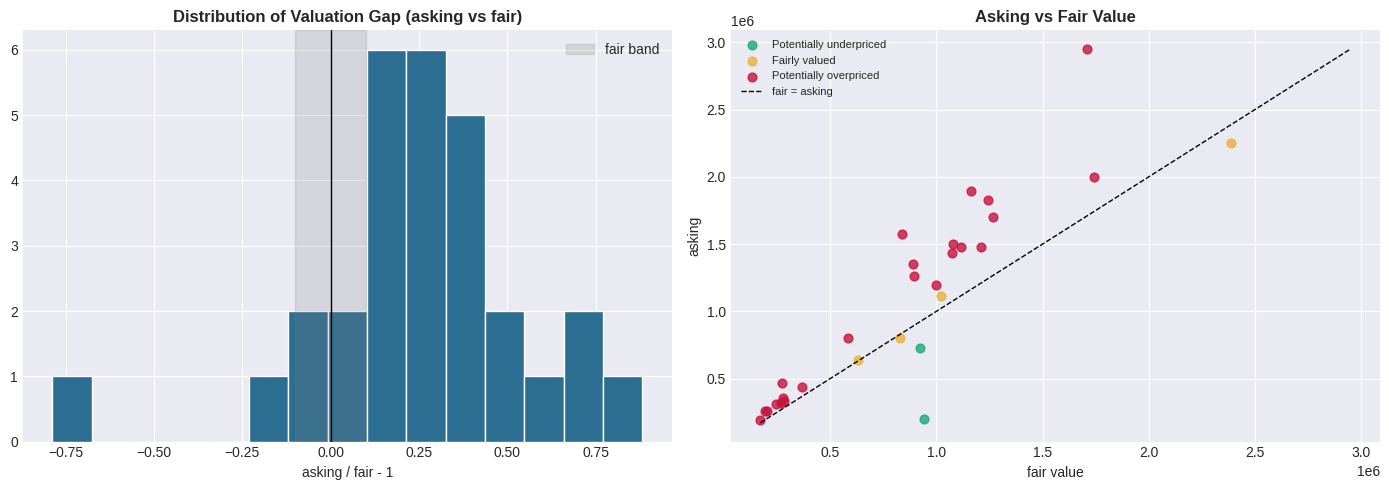

In [83]:
PAL = {"Potentially underpriced":"#19A979","Fairly valued":"#E8B23A",
       "Potentially overpriced":"#C8133B"}

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(df["valuation_gap_pct"], bins=15, color="#2C6E91", edgecolor="white")
ax[0].axvspan(-band, band, color="gray", alpha=0.2, label="fair band")
ax[0].axvline(0, color="black", lw=1)
ax[0].set_title("Distribution of Valuation Gap (asking vs fair)")
ax[0].set_xlabel("asking / fair - 1"); ax[0].legend()

for lab, c in PAL.items():
    s = df[df["valuation_label"]==lab]
    ax[1].scatter(s["fair_value"], s["asking_price"], c=c, label=lab, alpha=0.8, s=40)
lim = [df[["fair_value","asking_price"]].min().min(), df[["fair_value","asking_price"]].max().max()]
ax[1].plot(lim, lim, "k--", lw=1, label="fair = asking")
ax[1].set_title("Asking vs Fair Value"); ax[1].set_xlabel("fair value"); ax[1].set_ylabel("asking")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

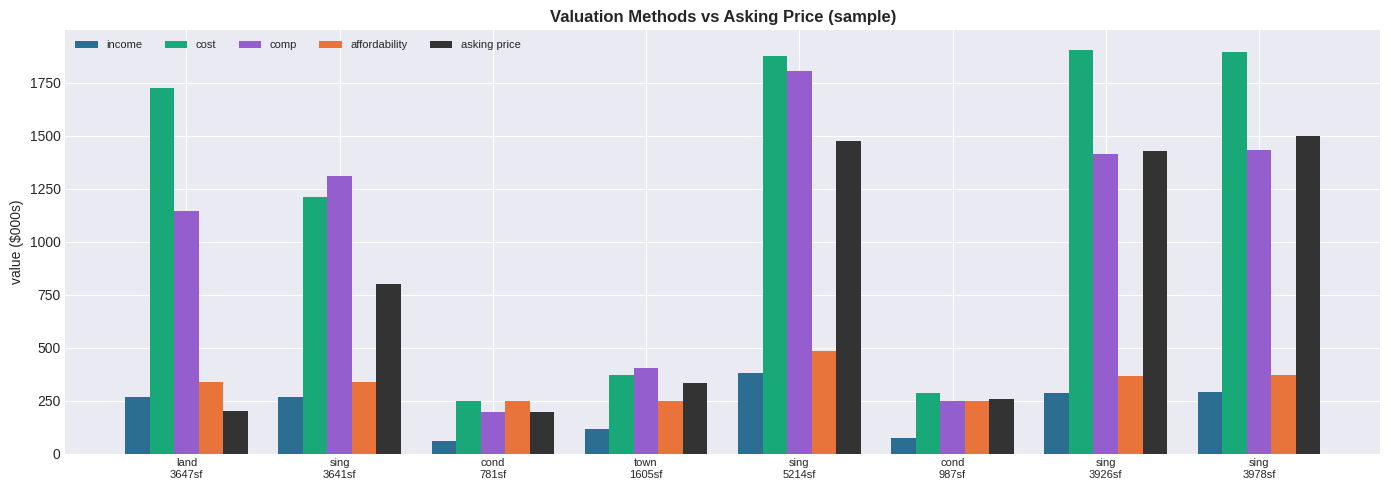

In [84]:
# Per-method comparison for a sample of homes
sample = df.sort_values("valuation_gap_pct").iloc[::max(len(df)//8,1)].head(8)
methods = ["income_value","cost_value","comp_value","affordability_value","asking_price"]
xpos = np.arange(len(sample)); width = 0.16
fig, ax = plt.subplots(figsize=(14, 5))
colors = ["#2C6E91","#19A979","#945ECF","#E8743B","#333333"]
for j, m in enumerate(methods):
    ax.bar(xpos+j*width, sample[m]/1000, width, label=m.replace("_value","").replace("_"," "),
           color=colors[j])
ax.set_xticks(xpos+2*width)
ax.set_xticklabels([f"{r.property_type[:4]}\n{r.sqft:.0f}sf" for r in sample.itertuples()],
                   fontsize=8)
ax.set_ylabel("value ($000s)"); ax.set_title("Valuation Methods vs Asking Price (sample)")
ax.legend(fontsize=8, ncol=5)
plt.tight_layout(); plt.show()

## Map

Green = underpriced, amber = fair, red = overpriced. Marker opacity grows with method
agreement, so high-conviction calls stand out. The map is saved to HTML; GitHub won't render
it inside the notebook, so screenshot it for your README.

In [85]:
required_map = ["latitude","longitude","valuation_gap_pct"]
assert not [c for c in required_map if c not in df.columns]
assert df["latitude"].between(35.75, 36.10).all()
assert df["longitude"].between(-79.25, -78.85).all()
print("Map data checks passed.")

def gap_color(g):
    if g <= -band: return "#19A979"
    if g >= band:  return "#C8133B"
    return "#E8B23A"

fmap = folium.Map(location=[CENTER["lat"], CENTER["lon"]], zoom_start=12, tiles="cartodbpositron")
for _, r in df.iterrows():
    folium.CircleMarker(
        [r["latitude"], r["longitude"]],
        radius=6 + r["asking_price"]/300000,
        color=gap_color(r["valuation_gap_pct"]), fill=True,
        fill_color=gap_color(r["valuation_gap_pct"]),
        fill_opacity=0.35 + 0.2*r["method_agreement"], weight=1,
        popup=folium.Popup(
            f"<b>{r['address']}</b><br>{r['property_type']}, {r['beds']}bd/{r['baths']}ba, "
            f"{r['sqft']:.0f} sqft<br>Asking: ${r['asking_price']:,.0f}<br>"
            f"Fair value: ${r['fair_value']:,.0f}<br>Gap: {r['valuation_gap_pct']:+.1%}<br>"
            f"<b>{r['valuation_label']}</b> (agreement {r['method_agreement']}/3)<br>"
            f"income ${r['income_value']:,.0f} | cost ${r['cost_value']:,.0f} | "
            f"comp ${r['comp_value']:,.0f} | afford ${r['affordability_value']:,.0f}",
            max_width=320)).add_to(fmap)

legend = """<div style="position:fixed;bottom:30px;left:30px;z-index:9999;background:white;
padding:10px;border:1px solid #888;border-radius:6px;font-size:13px">
<b>Valuation</b><br>
<span style="color:#19A979">&#9679;</span> Underpriced<br>
<span style="color:#E8B23A">&#9679;</span> Fairly valued<br>
<span style="color:#C8133B">&#9679;</span> Overpriced</div>"""
fmap.get_root().html.add_child(folium.Element(legend))
fmap.save("/content/chapel_hill_valuation_map.html")
print("Map saved to /content/chapel_hill_valuation_map.html")
fmap

Map data checks passed.
Map saved to /content/chapel_hill_valuation_map.html


## Final Ranked Tables

In [86]:
cols = ["address","property_type","beds","baths","sqft","asking_price","income_value",
        "cost_value","comp_value","affordability_value","fair_value","valuation_gap_pct",
        "valuation_label","method_agreement"]
fmt = {c:"${:,.0f}" for c in ["asking_price","income_value","cost_value","comp_value",
       "affordability_value","fair_value"]}
fmt["valuation_gap_pct"] = "{:+.1%}"

print("Top potentially UNDERPRICED")
display(df.sort_values("valuation_gap_pct").head(10)[cols].style.format(fmt)
        .background_gradient(subset=["valuation_gap_pct"], cmap="RdYlGn_r"))

print("Top potentially OVERPRICED")
display(df.sort_values("valuation_gap_pct", ascending=False).head(10)[cols].style.format(fmt)
        .background_gradient(subset=["valuation_gap_pct"], cmap="RdYlGn_r"))

Top potentially UNDERPRICED


,address,property_type,beds,baths,sqft,asking_price,income_value,cost_value,comp_value,affordability_value,fair_value,valuation_gap_pct,valuation_label,method_agreement
15,"244 Brown Bear, Chapel Hill, NC 27517",land,4.000000,4.500000,3647.000000,"$199,000","$267,622","$1,727,566","$1,147,091","$339,187","$940,789",-78.8%,Potentially underpriced,3
18,"245 N Crest Dr, Chapel Hill, NC 27517",single family,5.000000,4.000000,3551.000000,"$725,000","$260,577","$1,540,482","$1,315,002","$330,258","$923,130",-21.5%,Potentially underpriced,1
4,"40002 Worth, Chapel Hill, NC 27517",single family,6.000000,6.000000,10393.000000,"$2,249,000","$762,652","$3,547,642","$3,761,228","$966,593","$2,388,909",-5.9%,Fairly valued,1
28,"30054 Village Park Dr, Chapel Hill, NC 27517",single family,5.000000,5.000000,3641.000000,"$800,000","$267,181","$1,212,071","$1,312,828","$338,629","$826,373",-3.2%,Fairly valued,1
16,"39 Monteith Dr, Chapel Hill, NC 27516",single family,3.000000,2.500000,2672.000000,"$635,000","$196,075","$987,953","$939,131","$250,000","$630,262",+0.8%,Fairly valued,2
11,"126 Black Bear Ct, Chapel Hill, NC 27516",single family,5.000000,4.500000,3682.000000,"$1,115,000","$270,190","$1,785,034","$1,394,662","$342,442","$1,021,850",+9.1%,Fairly valued,2
25,"1001 Kingswood Dr, Apt J, Chapel Hill, NC 27517",condo,1.000000,1.000000,781.000000,"$194,000","$57,311","$247,421","$196,829","$250,000","$169,966",+14.1%,Potentially overpriced,1
5,"122 W Beech Slope Ct, Chapel Hill, NC 27517",single family,5.000000,8.500000,6159.000000,"$1,995,000","$451,956","$2,926,757","$2,540,778","$572,813","$1,743,813",+14.4%,Potentially overpriced,2
3,"165 Springberry Ln, Unit 165, Chapel Hill, NC 27517",condo,2.000000,2.500000,1353.000000,"$318,900","$99,285","$389,664","$356,463","$250,000","$268,090",+19.0%,Potentially overpriced,2
2,"1 Vauxhall Pl, Chapel Hill, NC 27517",townhouse,3.000000,3.000000,1605.000000,"$335,000","$117,777","$369,144","$405,878","$250,000","$280,871",+19.3%,Potentially overpriced,2


Top potentially OVERPRICED


,address,property_type,beds,baths,sqft,asking_price,income_value,cost_value,comp_value,affordability_value,fair_value,valuation_gap_pct,valuation_label,method_agreement
14,"594 Cedar Lake Rd, Unit A, Chapel Hill, NC 27516",multi-family,6.000000,4.000000,4416.000000,"$1,575,000","$324,052","$1,271,808","$1,173,217","$410,707","$836,592",+88.3%,Potentially overpriced,3
17,"197 Lakeside Dr, Chapel Hill, NC 27517",single family,4.000000,6.500000,6364.000000,"$2,950,000","$466,999","$3,054,720","$2,225,655","$591,879","$1,710,303",+72.5%,Potentially overpriced,2
31,"68 Willow Way, Chapel Hill, NC 27516",single family,4.000000,2.000000,1356.000000,"$465,000","$99,505","$390,528","$374,840","$250,000","$273,064",+70.3%,Potentially overpriced,3
21,"586 Poythress Rd, Chapel Hill, NC 27516",single family,4.000000,3.500000,4251.000000,"$1,895,000","$311,944","$2,081,290","$1,515,516","$395,361","$1,162,062",+63.1%,Potentially overpriced,2
8,"151 Swan Lake Ct, Chapel Hill, NC 27517",single family,4.000000,3.500000,3400.000000,"$1,350,000","$249,497","$1,648,320","$1,081,880","$316,215","$891,645",+51.4%,Potentially overpriced,2
39,"176 Clementine Way, Chapel Hill, NC 27516",single family,5.000000,4.000000,4501.000000,"$1,825,000","$330,289","$2,182,085","$1,673,204","$418,612","$1,241,155",+47.0%,Potentially overpriced,2
22,"690 Bear Tree Crk, Chapel Hill, NC 27517",single family,4.000000,3.500000,3412.000000,"$1,265,000","$250,377","$1,654,138","$1,085,698","$317,331","$894,792",+41.4%,Potentially overpriced,2
19,"15 Golfers Ridge Ct, Chapel Hill, NC 27517",single family,4.000000,3.500000,3978.000000,"$1,500,000","$291,911","$1,895,530","$1,434,228","$369,971","$1,075,713",+39.4%,Potentially overpriced,2
29,"71002 Everard, Chapel Hill, NC 27517",single family,3.000000,2.500000,2511.000000,"$799,000","$184,261","$976,014","$792,046","$250,000","$585,385",+36.5%,Potentially overpriced,2
35,"10363 Nash, Chapel Hill, NC 27517",single family,5.000000,5.000000,4668.000000,"$1,700,000","$342,544","$2,164,584","$1,764,203","$434,144","$1,264,701",+34.4%,Potentially overpriced,2
